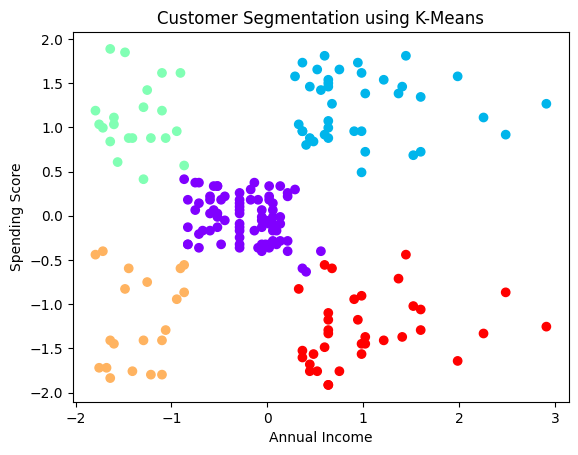

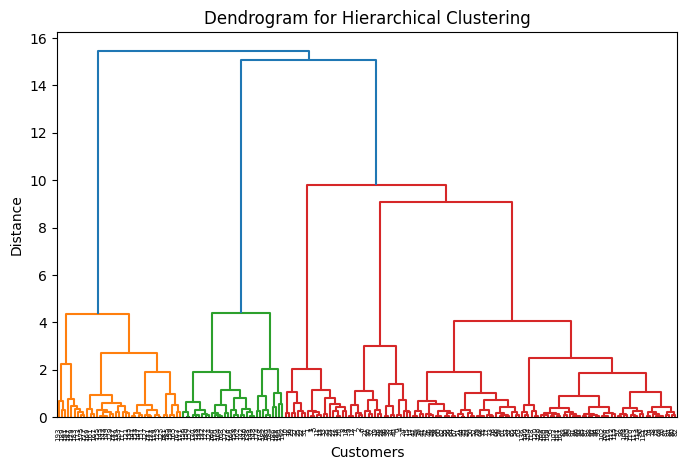

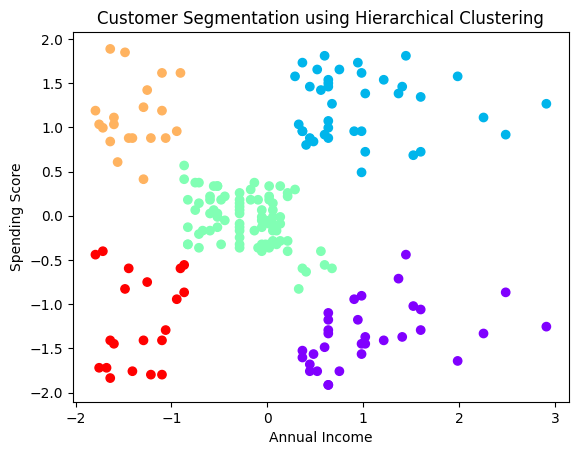

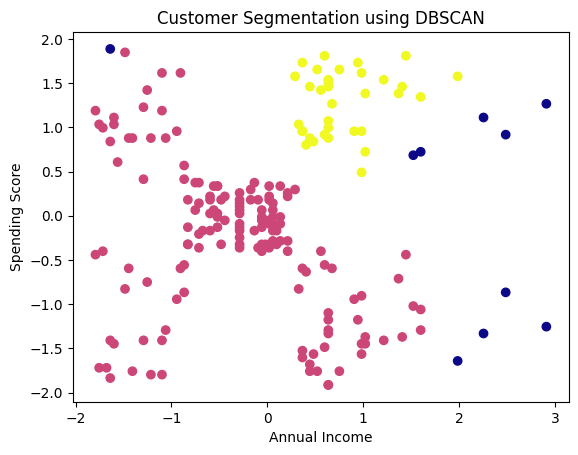

K-Means Clusters:
 [3 2 3 2 3 2 3 3 2 3 2 2 3 2 2 3 2 3 2 3 2 3 2 2 3 2 3 2 3 2 3 2 3 2 3 2 3
 2 3 0 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 4 1 0 1 4 1 4 1 0 1 4 1 4 1 4 1 4 1 0 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4
 1 4 1 4 1 4 1 4 1]
Hierarchical Clusters:
 [4 3 4 3 4 3 4 4 3 4 3 3 4 3 3 4 3 4 3 4 3 4 3 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 2 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 1 2 1 2 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 2 1 0 1 2 1 0 1 0 1 0 1
 0 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1]
DBSCAN Clusters:
 [ 0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

data = pd.read_csv(r"C:\Users\Akilan\OneDrive\Documents\MLT\DATA_BASE\Mall_Customers_Int.csv")

X = data[['Annual_Income_(k$)', 'Spending_Score']]

# 🔥 FIX: remove missing values
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=0)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels, cmap='rainbow')
plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

hc = AgglomerativeClustering(n_clusters=5)
hc_labels = hc.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels, cmap='rainbow')
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=db_labels, cmap='plasma')
plt.title("Customer Segmentation using DBSCAN")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

print("K-Means Clusters:\n", kmeans_labels)
print("Hierarchical Clusters:\n", hc_labels)
print("DBSCAN Clusters:\n", db_labels)